In [15]:
# ════════════════════════════════════════════════════════════════
# CNN 2D MEL — Pipeline corrigé (sans data leakage)
# Split par fichier source + augmentation uniquement sur train
# ════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, balanced_accuracy_score,
                              accuracy_score)
from pathlib import Path
import json

WAV_DIR    = Path("C:/Users/asalou/S7/stages7/project/wav_audio")
LAB_DIR    = Path("C:/Users/asalou/S7/stages7/project/labels")
OUTPUT_DIR = Path("C:/Users/asalou/S7/stages7/project/augmentation/aug")
TARGET_SR  = 16000
SEG_LEN    = 8000   # 500ms
HOP_LEN_AUD= 4000   # 250ms — chevauchement 50% pour train
N_MELS, N_FFT, HOP_MEL = 64, 512, 160
TARGET_PAR_CLASSE = 1500

# ── Charger dataset ───────────────────────────────────────────
dataset = {}
for file in WAV_DIR.glob("*.wav"):
    y, sr = librosa.load(file, sr=TARGET_SR)
    dataset[file.stem] = {'filtered': y.copy(), 'sr': sr}
print(f"Dataset chargé : {len(dataset)} fichiers")

# ── Charger labels ────────────────────────────────────────────
with open(f'{OUTPUT_DIR}/labels_segments.json') as f:
    labels_check = json.load(f)
print(f"Labels chargés : {len(labels_check)} fichiers")

Dataset chargé : 21 fichiers
Labels chargés : 21 fichiers


In [16]:
# ── Fusion silence → bruit_ambiant ───────────────────────────
print("Avant fusion :")
toutes = {}
for nom, labels in labels_check.items():
    for l in labels:
        toutes[l] = toutes.get(l, 0) + 1
print(toutes)

for nom in labels_check:
    labels_check[nom] = [
        'bruit_ambiant' if l == 'silence' else l
        for l in labels_check[nom]
    ]

print("\nAprès fusion (silence → bruit_ambiant) :")
toutes = {}
for nom, labels in labels_check.items():
    for l in labels:
        toutes[l] = toutes.get(l, 0) + 1
print(toutes)

Avant fusion :
{'bruit_ambiant': 463, 'miction_active': 782, 'silence': 156, 'bruit_chasse': 222}

Après fusion (silence → bruit_ambiant) :
{'bruit_ambiant': 619, 'miction_active': 782, 'bruit_chasse': 222}


In [19]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 1 — SPLIT PAR FICHIER SOURCE (pas par segment)
# ════════════════════════════════════════════════════════════════

fichiers = [f for f in labels_check.keys() if f in dataset]
print(f"Fichiers disponibles : {len(fichiers)}")

# Split 80% train / 20% test → ~17 train / ~4 test
fichiers_train, fichiers_test = train_test_split(
    fichiers, test_size=0.20, random_state=42)

print(f"\nSplit par fichier :")
print(f"  Train : {len(fichiers_train)} fichiers → {fichiers_train}")
print(f"  Test  : {len(fichiers_test)}  fichiers → {fichiers_test}")

Fichiers disponibles : 21

Split par fichier :
  Train : 16 fichiers → ['Audio_14', 'Audio_2', 'Audio_12', 'Audio_8', 'Audio_6', 'Audio_3', 'Audio_11', 'Audio_18', 'Bruit de pipi (mp3cut.net)', 'Audio_13', 'Audio_20', 'Audio_16', 'Audio_19', 'Audio_4', 'Audio_9', 'Audio_15']
  Test  : 5  fichiers → ['Audio_1', 'Audio_7', 'Audio_5', 'Audio_10', 'Audio_17']


In [20]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 2 — SEGMENTATION
# Train : chevauchement 50% (hop=250ms)
# Test  : sans chevauchement (hop=500ms) — segments originaux
# ════════════════════════════════════════════════════════════════

def segmenter(fichiers_liste, hop, labels_check, dataset):
    """
    Segmente les fichiers audio et attribue les labels
    par héritage du segment original au centre.
    """
    segments_par_classe = {
        'miction_active': [],
        'bruit_ambiant':  [],
        'bruit_chasse':   [],
        'silence':        [],
    }

    for nom in fichiers_liste:
        filt        = dataset[nom]['filtered']
        sr          = dataset[nom]['sr']
        labels_orig = labels_check[nom]
        n_orig      = len(labels_orig)
        pos         = 0

        while pos + SEG_LEN <= len(filt):
            segment  = filt[pos:pos + SEG_LEN]

            # Label hérité par le centre du segment
            centre_s = (pos + SEG_LEN // 2) / sr
            orig_id  = min(int(centre_s / 0.5), n_orig - 1)
            lbl      = labels_orig[orig_id]

            if lbl in segments_par_classe:
                segments_par_classe[lbl].append(segment.copy())

            pos += hop

    return segments_par_classe


# Segmentation train (chev. 50% → hop=4000)
print("Segmentation TRAIN (chevauchement 50%)...")
segs_train = segmenter(fichiers_train, HOP_LEN_AUD, labels_check, dataset)
print("Distribution train :")
for lbl, segs in segs_train.items():
    print(f"  {lbl:20s} : {len(segs)}")

# Segmentation test (sans chev. → hop=8000)
print("\nSegmentation TEST (sans chevauchement)...")
segs_test = segmenter(fichiers_test, SEG_LEN, labels_check, dataset)
print("Distribution test :")
for lbl, segs in segs_test.items():
    print(f"  {lbl:20s} : {len(segs)}")

Segmentation TRAIN (chevauchement 50%)...
Distribution train :
  miction_active       : 1188
  bruit_ambiant        : 954
  bruit_chasse         : 352
  silence              : 0

Segmentation TEST (sans chevauchement)...
Distribution test :
  miction_active       : 188
  bruit_ambiant        : 135
  bruit_chasse         : 50
  silence              : 0


In [22]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 3 — AUGMENTATION UNIQUEMENT SUR TRAIN
# ════════════════════════════════════════════════════════════════

def aug_bruit(seg, sr, sigma=0.005):
    return seg + np.random.normal(0, sigma, len(seg))

def aug_gain(seg, sr, low=0.7, high=1.3):
    return seg * np.random.uniform(low, high)

def aug_shift(seg, sr, max_ms=50):
    shift = int(np.random.uniform(-max_ms, max_ms) * sr / 1000)
    return np.roll(seg, shift)

def aug_stretch(seg, sr, low=0.9, high=1.1):
    rate = np.random.uniform(low, high)
    stretched = librosa.effects.time_stretch(seg.astype(float), rate=rate)
    if len(stretched) >= SEG_LEN:
        return stretched[:SEG_LEN]
    return np.pad(stretched, (0, SEG_LEN - len(stretched)))

def aug_pitch(seg, sr, steps=(-2,-1,1,2)):
    n = np.random.choice(steps)
    return librosa.effects.pitch_shift(seg.astype(float), sr=sr, n_steps=n)

def augmenter(seg, sr):
    methodes = [aug_gain, aug_shift, aug_stretch, aug_pitch]
    methode  = np.random.choice(methodes)
    seg_aug  = methode(seg, sr)
    seg_aug  = aug_bruit(seg_aug, sr, sigma=np.random.uniform(0.001, 0.008))
    mx = np.max(np.abs(seg_aug))
    if mx > 0:
        seg_aug = seg_aug / mx * np.max(np.abs(seg))
    return seg_aug.astype(np.float32)


np.random.seed(42)
print(f"Augmentation TRAIN → {TARGET_PAR_CLASSE} par classe")
print("="*55)

X_train_list, y_train_list = [], []

for lbl, segs_orig in segs_train.items():
    n_orig   = len(segs_orig)
    n_needed = max(0, TARGET_PAR_CLASSE - n_orig)
    tous     = list(segs_orig)

    if n_orig == 0:
        print(f"  {lbl:20s} : VIDE — ignoré")
        continue
    
    n_needed = max(0, TARGET_PAR_CLASSE - n_orig)
    tous     = list(segs_orig)


    for _ in range(n_needed):
        src = segs_orig[np.random.randint(len(segs_orig))]
        tous.append(augmenter(src, TARGET_SR))

    X_train_list.extend(tous)
    y_train_list.extend([lbl] * len(tous))
    print(f"  {lbl:20s} : {n_orig} + {n_needed} augmentés = {len(tous)}")

print(f"\nTotal train : {len(X_train_list)} segments")

# Test — pas d'augmentation
X_test_list, y_test_list = [], []
for lbl, segs in segs_test.items():
    X_test_list.extend(segs)
    y_test_list.extend([lbl] * len(segs))

print(f"Total test  : {len(X_test_list)} segments")
print("\nDistribution test (non augmenté) :")
print(pd.Series(y_test_list).value_counts().to_string())

Augmentation TRAIN → 1500 par classe
  miction_active       : 1188 + 312 augmentés = 1500
  bruit_ambiant        : 954 + 546 augmentés = 1500
  bruit_chasse         : 352 + 1148 augmentés = 1500
  silence              : VIDE — ignoré

Total train : 4500 segments
Total test  : 373 segments

Distribution test (non augmenté) :
miction_active    188
bruit_ambiant     135
bruit_chasse       50


In [23]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 4 — CONVERSION EN SPECTROGRAMMES MEL
# ════════════════════════════════════════════════════════════════

def signal_to_melspec(segment):
    mel = librosa.feature.melspectrogram(
        y=segment.astype(float), sr=TARGET_SR,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_MEL, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn > 0:
        return ((mel_db - mn) / (mx - mn)).astype(np.float32)
    return np.zeros_like(mel_db, dtype=np.float32)


print("Conversion train → spectrogrammes Mel...")
X_train_mel = np.array([signal_to_melspec(s)
                         for s in X_train_list], dtype=np.float32)
X_train_mel = X_train_mel[..., np.newaxis]
print(f"X_train_mel : {X_train_mel.shape}")

print("Conversion test  → spectrogrammes Mel...")
X_test_mel = np.array([signal_to_melspec(s)
                        for s in X_test_list], dtype=np.float32)
X_test_mel = X_test_mel[..., np.newaxis]
print(f"X_test_mel  : {X_test_mel.shape}")

# Encodage labels
le = LabelEncoder()
le.fit(list(segs_train.keys()))  # fit sur les 4 classes connues

y_train_enc = le.transform(y_train_list)
y_test_enc  = le.transform(y_test_list)
print(f"\nClasses : {le.classes_}")

# Shuffle train
idx = np.random.permutation(len(X_train_mel))
X_train_mel  = X_train_mel[idx]
y_train_enc  = y_train_enc[idx]

# Split train → train + validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_mel, y_train_enc,
    test_size=0.15, stratify=y_train_enc, random_state=42)

print(f"\nSplit final :")
print(f"  Train : {len(X_tr)}")
print(f"  Val   : {len(X_val)}")
print(f"  Test  : {len(X_test_mel)} (fichiers jamais vus)")

Conversion train → spectrogrammes Mel...
X_train_mel : (4500, 64, 51, 1)
Conversion test  → spectrogrammes Mel...
X_test_mel  : (373, 64, 51, 1)

Classes : ['bruit_ambiant' 'bruit_chasse' 'miction_active' 'silence']

Split final :
  Train : 3825
  Val   : 675
  Test  : 373 (fichiers jamais vus)


In [24]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 5 — ARCHITECTURE CNN 2D
# ════════════════════════════════════════════════════════════════

def build_cnn2d(input_shape=(64, 51, 1), n_classes=3):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

# Adapter input_shape à la vraie taille du spectrogramme
input_shape = X_tr.shape[1:]
print(f"Input shape CNN : {input_shape}")

model = build_cnn2d(input_shape=input_shape, n_classes=4)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

Input shape CNN : (64, 51, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 64, 51, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 51, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 51, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 25, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 25, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 16, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 127,620 (498.52 KB)

 Trainable params: 127,172 (496.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 6 — ENTRAÎNEMENT
# ════════════════════════════════════════════════════════════════

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(
        f'{OUTPUT_DIR}/cnn2d_corrige.keras',
        monitor='val_loss', save_best_only=True),
]

history = model.fit(
    X_tr, y_tr,
    epochs=60,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 259ms/step - accuracy: 0.6319 - loss: 0.8633 - val_accuracy: 0.3319 - val_loss: 1.4899 - learning_rate: 0.0010
Epoch 2/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.7663 - loss: 0.5700 - val_accuracy: 0.3333 - val_loss: 1.8736 - learning_rate: 0.0010
Epoch 3/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - accuracy: 0.8180 - loss: 0.4679 - val_accuracy: 0.3333 - val_loss: 2.3211 - learning_rate: 0.0010
Epoch 4/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.8280 - loss: 0.4294 - val_accuracy: 0.3333 - val_loss: 2.9874 - learning_rate: 0.0010
Epoch 5/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 256ms/step - accuracy: 0.8478 - loss: 0.3889 - val_accuracy: 0.5111 - val_loss: 3.0523 - learning_rate: 0.0010
Epoch 6/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 253ms/step - accuracy: 0.8635 - loss: 0.3522 - val_accuracy: 0.4059 - val_loss: 3.3596 - learning_rate: 0.0010
Epoch 7/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 256ms/step - accuracy: 0.8805 - loss: 0.

RÉSULTATS — Test set (fichiers jamais vus)
Accuracy          : 0.810
Balanced Accuracy : 0.806

              precision    recall  f1-score   support

           0      0.703     0.896     0.788       135
           1      1.000     0.760     0.864        50
           2      0.877     0.761     0.815       188

    accuracy                          0.810       373
   macro avg      0.860     0.806     0.822       373
weighted avg      0.831     0.810     0.812       373



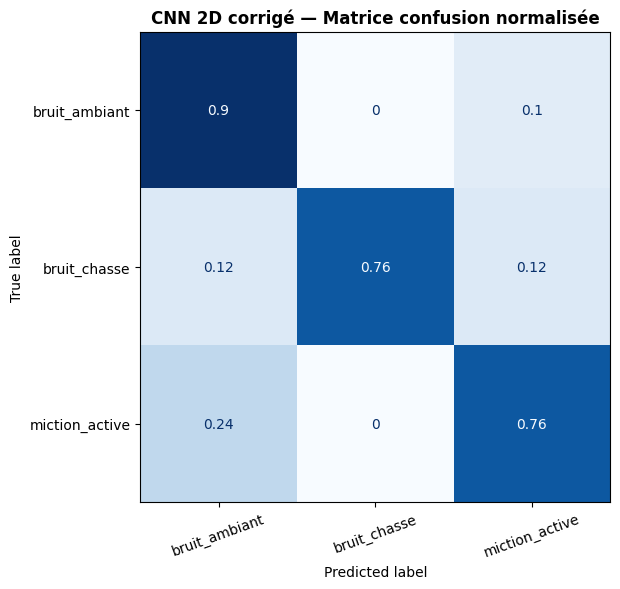


COMPARAISON
Modèle                              |  Bal.Acc
-------------------------------------------------------
SVM RBF                             |    0.777
CNN 2D original (leakage)           |    0.877
CNN 2D corrigé (propre)             |    0.806


In [28]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 7 — ÉVALUATION FINALE SUR TEST (fichiers jamais vus)
# ════════════════════════════════════════════════════════════════

y_pred = np.argmax(model.predict(X_test_mel, verbose=0), axis=1)

acc = accuracy_score(y_test_enc, y_pred)
bal = balanced_accuracy_score(y_test_enc, y_pred)

print("="*60)
print("RÉSULTATS — Test set (fichiers jamais vus)")
print("="*60)
print(f"Accuracy          : {acc:.3f}")
print(f"Balanced Accuracy : {bal:.3f}")
print()
print(classification_report(
    y_test_enc, y_pred, digits=3))

# Matrice de confusion
cm      = confusion_matrix(y_test_enc, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_norm.round(2),
    display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('CNN 2D corrigé — Matrice confusion normalisée',
             fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnn2d_corrige_confusion.png',
            dpi=120, bbox_inches='tight')
plt.show()

# Comparaison
print("\n" + "="*55)
print("COMPARAISON")
print("="*55)
print(f"{'Modèle':35s} | {'Bal.Acc':>8}")
print("-"*55)
print(f"{'SVM RBF':35s} | {'0.777':>8}")
print(f"{'CNN 2D original (leakage)':35s} | {'0.877':>8}")
print(f"{'CNN 2D corrigé (propre)':35s} | {bal:8.3f}")
print("="*55)

In [11]:
# Eval sur 3 classes seulement (exclure silence)
from sklearn.metrics import balanced_accuracy_score

mask = y_test_enc != le.transform(['silence'])[0]
bal_3cls = balanced_accuracy_score(
    y_test_enc[mask], y_pred[mask])
print(f"Bal.Acc sans silence : {bal_3cls:.3f}")

Bal.Acc sans silence : 0.737


C:\Users\asalou\S7\envs\stages7\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [13]:
for nom in fichiers_train:
    n_sil = labels_check[nom].count('silence')
    if n_sil > 0:
        print(f"  {nom:20s} : {n_sil} segments silence")

  Audio_8              : 28 segments silence
  Audio_3              : 24 segments silence
  Audio_11             : 5 segments silence
  Bruit de pipi (mp3cut.net) : 12 segments silence
  Audio_13             : 10 segments silence
  Audio_20             : 6 segments silence
  Audio_16             : 20 segments silence
  Audio_19             : 28 segments silence
  Audio_4              : 10 segments silence
